### Examples of nutrient-phytoplankton-zooplankton (NPZ) modelling
 Based on Peter Frank (1986): Simple NPZ model
 
************************************

**Goal**: To provide some experience in running, modifying and interpreting a simple Nutrient-Phytoplankton-Zooplankton model.

********************************************
 



### Introduction:

One of the goals of biological oceanography is to understand the interactions between nutrient availability, phytoplankton biomass (which depends on the phytoplankton growth rate, mortality, grazing of phytoplankton by zooplankton, physical mixing and sinking) and zooplankton biomass (which depends on their grazing of phytoplankton and mortality). Here we use a basic nutrient-phytoplankton-zooplankton (NPZ) model of the upper water column (a temperate ocean mixed layer) based on a 1986 paper by Peter Franks – see franks_npz_model.pdf.

In this model, nutrients (N, probably mostly as NO3) are taken up by phytoplankton and converted into phytoplankton biomass (or ‘stock’). Phytoplankton are grazed (eaten) by zooplankton and converted into zooplankton biomass but the process is not 100% efficient, there are losses due to metabolism. These losses are excreted back into the dissolved nutrient pool (as NH4) and are available to phytoplankton. Both phytoplankton and zooplankton die and decay and are remineralised back into the dissolved nutrient pool which is again available to phytoplankton. Note that the system is closed – there is no net flux of anything in or out (until we implement it later in the exercise). All three ‘pools’ (N, P and Z) are expressed in units of the concentration of N [micro M or its equivalent unit mmol m-3]. This is known as the ‘currency’ of the model.

Note: For validating model output, N is an inconvenient term because there are few observations of particulate organic N (PON). Chlorophyll would be better because there are abundant chlorophyll observations. 
So some modellers use a N:chl conversion factor and compare phytoplankton stocks with satellite or in situ chlorophyll observations.

The model is described by a series of equations that describe how much is added or subtracted from each pool (P, Z and N) at each timestep. 
Each addition or subtraction corresponds to a physical process (i.e. photosynthesis or grazing). 
Note, because mass is conserved any addition to one pool must correspond to a subtraction from another. 

For this simple model, we can write the equations out in words like this:

Change in P = + nutrient uptake – P mortality (i.e. non-grazing death) – grazing

Change in Z = + grazing efficiency *Grazing – Z mortality (i.e. all death)

Change in N = – nutrient uptake + (1-grazing efficiency) * Grazing + P mortality + Z mortality 

Where, nutrient uptake is equal to the rate of photosynthesis (u) multiplied by the amount of phytoplankton (P). 

The rate of photosynthesis (u) is equal to a maximum phytoplankton growth rate (umax) scaled by a nutrient limitation term (LimN). In more complex models rate of photosynthesis is often also scaled by a temperature and light limitation term. 

The nutrient limitation term (LimN) is equal to a Michelis-Menton style function of the nutrient concentration (N). It starts at 0 when there are no nutrinent, increases rapidly as nutrients increase, then saturates toward 1 once nutrients become no longer limiting. The half saturation concentration for nutrient uptake (KN) determines at what concentration nutrients become limiting. Higher values means nutrients are more limiting. 

The grazing efficiency (γ) is equal to a single parameter value that expresses what fraction of phytoplankton grazed actually get used to ‘build’ zooplankton biomass. The rest is either not digested or metalized for energy. This portion is implicitly remineralized and put back into the inorganic nutrient pool. 

Grazing (G) is equal to the rate of grazing (g) multiplied by the amount of zooplankton (Z). 

The rate of grazing (g) is equal to the maximum grazing rate (gmax) scaled by a function of the phytoplankton population. Although this function looks mathematically different than the nutrient limitation term, it is qualitatively similar. Each individual zooplankton can graze at faster rate when there are more phytoplankton and it is thus easier to find and capture them. 

The P and Z mortality terms are equal to a mortality rate (mP, mZ )  multiplied by their respective populations (P, Z). 

All together, these relationships can be writtenathematically as: 

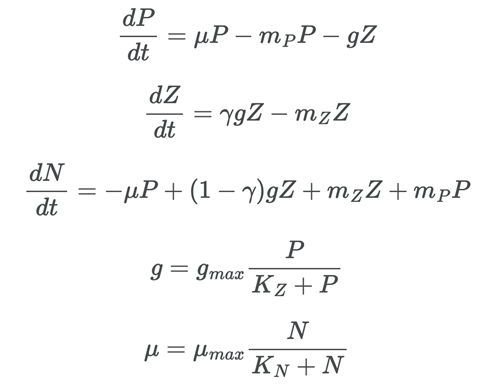


The variables (i.e. values that measure a physical quantity and change in time, aka tracers) and parameters (i.e. values the described the assumed rate of different processes) are summarized in the tables below. Note model variables (or tracers) are then physical quantities being modeled while parameters describe the assumptions the modeler has made about the processes that relate them.

The scenario we are simulating here is much like an idealized spring bloom in, say, the North Atlantic or Tasman Sea. We are in a mid-to-high latitude ocean around the beginning of spring when the water column has just stratified, nutrients are at moderate to high levels from winter mixing, and both phytoplankton and zooplankton biomass are low to begin.

The exercise consists of several parts. First, we’ll run the basic model, then we’ll tweak the parameters in different ways, look at the output and answer some questions.


### Part 1: Run a simplified NPZ model

**Initial Conditions**
|Parameter| Value |
|---|---|
|Nutrients                        |     N = 1.6 umol/l|
|Phytoplankton Biomass            |     P = 0.3 umol/l|
|Zooplankton Biomass              |    Z = 0.1 umol/l|
|max phyto growth rate            |    umax = 2.0 per day|
|phyto mortality                  |    mp = 0.1 per day|
|max zoo grazing                  |     gmax = 1.5 per day|
|zoo mortality                  |     mz = 0.2 per day|
|Grazing efficiency               |     Gamma = 0.3 |
|half sat conc nutrient uptake    |      KN = 1.6 umol/l|
|half sat conc zoo grazing        |     KZ = 0.7 umol/l|
|min phyto conc                   |                        P0 = 0 umol/l|


**Confirm all initial conditions and parameter values are consistent with the above values.**


In [10]:
import sys 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# where are we?
print(os.getcwd())

# adjust path to where you want to save the figures
path = '' 

/home/581/ao2582


In [50]:
# define function compute NPZ

def npz_model(ndays, nsteps, N, P, Z, umax, mp, gmax, mz, Gamma, KN, KZ, P0, mixingON=False, Mix=0.02, deepN=10.6, sp=0.6, sz=0.4):
    # Scale daily rates for small time steps
    umax /= nsteps                  # maximum phytoplankton growth rate
    mp /= nsteps                    # phytoplankton mortlality rate
    gmax /= nsteps                  # maximum zooplankton grazing rate
    mz /= nsteps                    # zooplankton mortlality rate
    Mix /= nsteps                   # mixing rate (fraction of box mixed per day) 

    # Initialize arrays with initial conditions
    Tct = np.array([0])
    Nct = np.array([N])
    Pct = np.array([P])
    Zct = np.array([Z])

    # Main loop
    ct = 0  # initialize timestep
    for i in range(ndays):
        # Autumn mixing if mixingON is set to True
        if mixingON and i > 120:
            Mix += 0.02 / nsteps

        # Subloop to allow nstep time steps per day
        for j in range(nsteps):
            ct += 1

            # Phytoplankton growth at given N concentration
            mu = umax * (N / (KN + N))

            # Prevent grazing if P is below minimum value (P0)
            graze = gmax * ((P - P0) / (KZ + (P - P0))) if P > P0 else 0

            # Compute differential equations
            delP = mu * P - mp * P - graze * Z
            delZ = Gamma * graze * Z - mz * Z

            if mixingON:
                delN = -mu * P + sp * mp * P + sz * mz * Z + sz * (1 - Gamma) * graze * Z + Mix * (deepN - N)
            else:
                delN = -mu * P + mp * P + mz * Z + (1 - Gamma) * graze * Z

            # Update values
            P += delP
            Z += delZ
            N += delN

            # add results to time series
            Tct = np.append(Tct, ct/nsteps)
            Nct = np.append(Nct, N)
            Pct = np.append(Pct, P)
            Zct = np.append(Zct, Z)

    return Tct, Nct, Pct, Zct

# helper function to unpack values from dataframe
def run_npz(params_df, index=0):
    row = params_df.iloc[index]
    return npz_model(
        ndays=row['ndays'],
        nsteps=row['nsteps'],
        N=row['N'],
        P=row['P'],
        Z=row['Z'],
        umax=row['umax'],
        mp=row['mp'],
        gmax=row['gmax'],
        mz=row['mz'],
        Gamma=row['Gamma'],
        KN=row['KN'],
        KZ=row['KZ'],
        P0=row['P0'],
        mixingON=row['mixingON'],
        Mix=row['Mix'],
        deepN=row['deepN'],
        sp=row['sp'],
        sz=row['sz']
    )


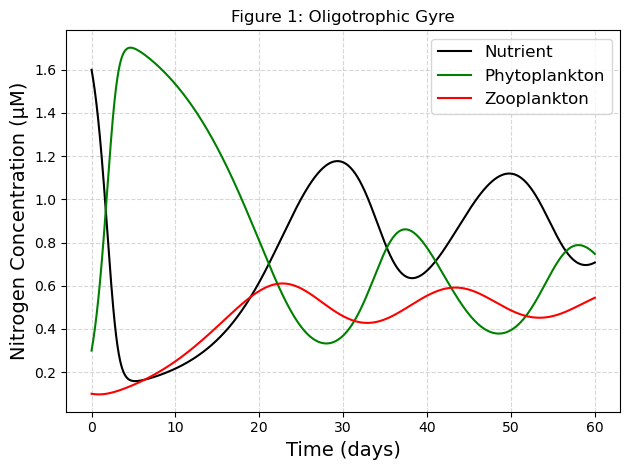

In [51]:
# compute NPZ with initial conditions

# initial conditions
###########################
ndays=60                     # days
nsteps=60                    # steps
N=1.6                        # nutrient concentration
P=0.3                        # phytoplankton biomass
Z=0.1                        # zooplankton biomass
umax=2.0                     # maximum phytoplankton growth rate
mp=0.1                       # phytoplankton mortlality rate
gmax=1.5                     # maximum zooplankton grazing rate
mz=0.2                       # zooplankton mortlality rate
Gamma=0.3                    # grazing efficiency
KN=1.6                       # half saturation concentration for nutrient uptake
KZ=0.7                       # half saturation concentration for grazing      
P0=0                         # minimum phytopankton threshold
# Mixing parameters
mixingON=False               # turn on and off using 'True' and 'False'
Mix=0.02                     # mixing rate (fraction of box mixed per day) 
deepN=10.6                   # nutrient concentration
sp=0.6                       # fraction of dead phytoplankton POC that sinks out of surface
sz=0.4                       # fraction of dead zooplankton and sloppy feeding POC that sinks out of surface



# for easy use we convert this into a Pandas Dataframe
params_init_df = pd.DataFrame([{
    'ndays': 60,
    'nsteps': 60,
    'N': 1.6,
    'P': 0.3,
    'Z': 0.1,
    'umax': 2.0,
    'mp': 0.1,
    'gmax': 1.5,
    'mz': 0.2,
    'Gamma': 0.3,
    'KN': 1.6,
    'KZ': 0.7,
    'P0': 0,
    'mixingON': False,
    'Mix': 0.02,
    'deepN': 10.6,
    'sp': 0.6,
    'sz': 0.4
}])

# now we can call the function 
Tct, Nct, Pct, Zct = run_npz(params_init_df)

# Plot results
plt.figure()
plt.plot(Tct, Nct, 'k', linewidth=1.5, label='Nutrient')
plt.plot(Tct, Pct, 'g', linewidth=1.5, label='Phytoplankton')
plt.plot(Tct, Zct, 'r', linewidth=1.5, label='Zooplankton')
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Nitrogen Concentration (µM)', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Figure 1: Oligotrophic Gyre')
plt.tight_layout()
# plt.savefig(path + 'Fig_1.png')  # uncomment to store figure locally
plt.show()

### Part 2: North Atlantic
A phytoplankton growth rate ($\mu$max) of 2 day$^{-1}$ is not very realistic.
It’s too high. A more realistic value would be 0.69 day$^{-1}$ which corresponds to one doubling per day (0.69 = ln(2)). Also, an initial nutrient (Nitrate, NO$^{-3}$) concentration of 1.6 $\mu$M is too low for our theoretical north Atlantic, let’s try 10.6 $\mu$M. Change these values in your script.

In [52]:
# compute NPZ with North Atlantic conditions

# TODO: update initial conditions:
# for easy use we convert this into a Pandas Dataframe
params_2_df = pd.DataFrame([{
    'ndays': 60,
    'nsteps': 60,
    'N': 10.6,
    'P': 0.3,
    'Z': 0.1,
    'umax': 0.69,
    'mp': 0.1,
    'gmax': 1.5,
    'mz': 0.2,
    'Gamma': 0.3,
    'KN': 1.6,
    'KZ': 0.7,
    'P0': 0,
    'mixingON': False,
    'Mix': 0.02,
    'deepN': 10.6,
    'sp': 0.6,
    'sz': 0.4
}])

print(params_2_df)

   ndays  nsteps     N    P    Z  umax   mp  gmax   mz  Gamma   KN   KZ  P0  \
0     60      60  10.6  0.3  0.1  0.69  0.1   1.5  0.2    0.3  1.6  0.7   0   

   mixingON   Mix  deepN   sp   sz  
0     False  0.02   10.6  0.6  0.4  


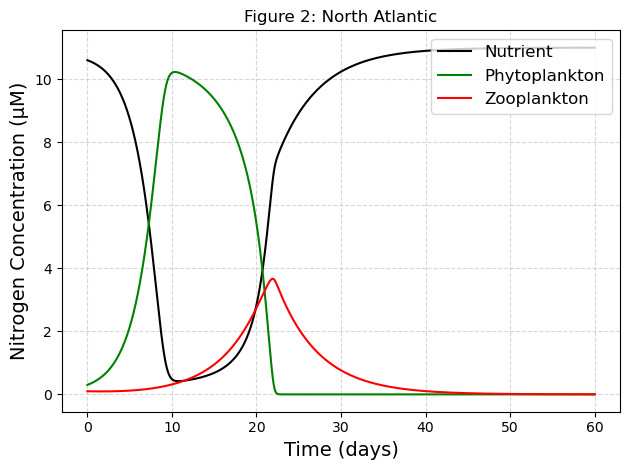

In [53]:
# now we can call the function 
Tct, Nct, Pct, Zct = run_npz(params_2_df)

# Plot results
# Plot results
plt.figure()
plt.plot(Tct, Nct, 'k', linewidth=1.5, label='Nutrient')
plt.plot(Tct, Pct, 'g', linewidth=1.5, label='Phytoplankton')
plt.plot(Tct, Zct, 'r', linewidth=1.5, label='Zooplankton')
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Nitrogen Concentration (µM)', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Figure 2: North Atlantic')
plt.tight_layout()
# plt.savefig(path + 'Fig_2.png')  # uncomment to store figure locally
plt.show()

*************************
#### Question 1. What are the main differences, if any, between Figure 1 and Figure 2 for all three pools of nitrogen (N, P, Z)? Explain how those differences came about, or not.
*************************

*************
**Answer:**

   - Fig 1: Oligotrophic gyres, smaller phytos so higher growth rate, fast recycling system
   - Fig 2: Spring bloom, complete ecological collapse, unrealistic

********

### Part 3: Minimum Phytoplankton Concentration
The script includes the option to set a minimum amount phytoplankton concentration (P0, or ‘P-zero’) that must be present before they start to be grazed. This can be invoked by setting P0 to a non-zero value. Set it to 1.0 and run the script.

In [54]:
# TODO: update initial conditions:

params_3_df = pd.DataFrame([{
    'ndays': 60,
    'nsteps': 60,
    'N': 10.6,
    'P': 0.3,
    'Z': 0.1,
    'umax': 0.69,
    'mp': 0.1,
    'gmax': 1.5,
    'mz': 0.2,
    'Gamma': 0.3,
    'KN': 1.6,
    'KZ': 0.7,
    'P0': 1,
    'mixingON': False,
    'Mix': 0.02,
    'deepN': 10.6,
    'sp': 0.6,
    'sz': 0.4
}])

print(params_3_df)

   ndays  nsteps     N    P    Z  umax   mp  gmax   mz  Gamma   KN   KZ  P0  \
0     60      60  10.6  0.3  0.1  0.69  0.1   1.5  0.2    0.3  1.6  0.7   1   

   mixingON   Mix  deepN   sp   sz  
0     False  0.02   10.6  0.6  0.4  


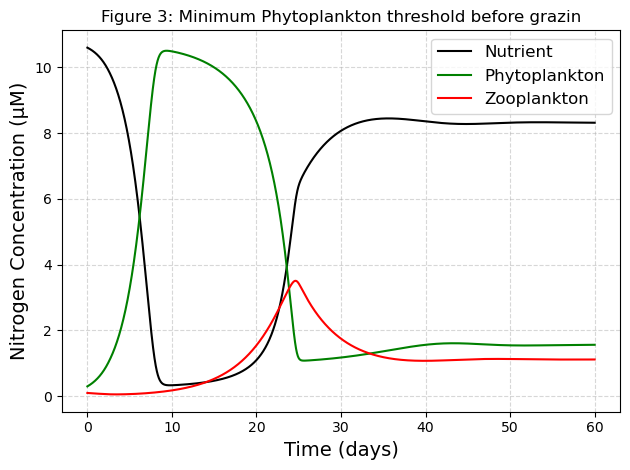

In [45]:
# compute NPZ with initial phytoplankton concentration
Tct, Nct, Pct, Zct = run_npz(params_3_df)

# Plot results
plt.figure()
plt.plot(Tct, Nct, 'k', linewidth=1.5, label='Nutrient')
plt.plot(Tct, Pct, 'g', linewidth=1.5, label='Phytoplankton')
plt.plot(Tct, Zct, 'r', linewidth=1.5, label='Zooplankton')
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Nitrogen Concentration (µM)', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Figure 3: Minimum Phytoplankton threshold before grazin')
plt.tight_layout()
# plt.savefig(path + 'Fig_3.png')  # uncomment to store figure locally
plt.show()

*********************
#### Question 2. What is the main difference between figure2 and figure3 and why? What ecological phenomenon is P0 trying to simulate?
********************

*********************
**Answer.** 
- Phytos keep slowly growing and nutrients are at low levels, low levels of phytos are kept -   simulating the hiding of phytos, at a threshold no more grazing

********************

### Part 4: Turn mixing on

The large amount of N that is regenerated as grazing occurs is not realistic. It happens because of the closed system. So, let’s move away from a model that operates in a closed upper mixed layer and allow some interaction with the ocean below. We will let some of the dead P and Z (mPP and mZZ) sink. We’ll also let some of the deep water mix into the surface waters, and we’ll lengthen the duration of the simulation. So, do this: (1) change ndays to 200, (2) turn mixing on by setting  mixingOn to'True'.
 


In [46]:
# TODO: update initial conditions:

params_4_df = pd.DataFrame([{
    'ndays': 200,
    'nsteps': 60,
    'N': 10.6,
    'P': 0.3,
    'Z': 0.1,
    'umax': 0.69,
    'mp': 0.1,
    'gmax': 1.5,
    'mz': 0.2,
    'Gamma': 0.3,
    'KN': 1.6,
    'KZ': 0.7,
    'P0': 1,
    'mixingON': True,
    'Mix': 0.02,
    'deepN': 10.6,
    'sp': 0.6,
    'sz': 0.4
}])

print(params_4_df)

   ndays  nsteps     N    P    Z  umax   mp  gmax   mz  Gamma   KN   KZ  P0  \
0    200      60  10.6  0.3  0.1  0.69  0.1   1.5  0.2    0.3  1.6  0.7   1   

   mixingON   Mix  deepN   sp   sz  
0      True  0.02   10.6  0.6  0.4  


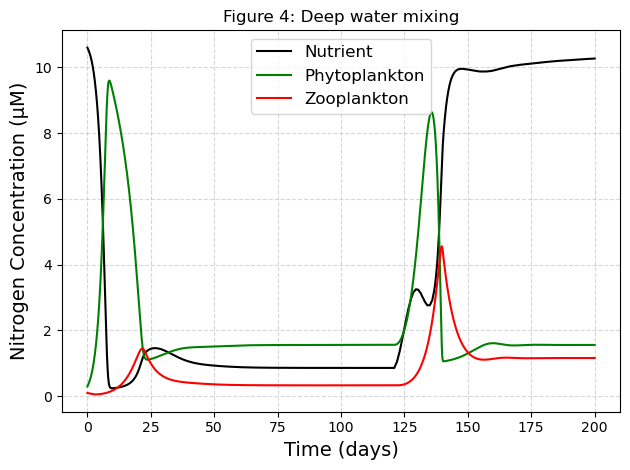

In [47]:
# compute NPZ with mixing
Tct, Nct, Pct, Zct = run_npz(params_4_df)

# Plot results
plt.figure()
plt.plot(Tct, Nct, 'k', linewidth=1.5, label='Nutrient')
plt.plot(Tct, Pct, 'g', linewidth=1.5, label='Phytoplankton')
plt.plot(Tct, Zct, 'r', linewidth=1.5, label='Zooplankton')
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Nitrogen Concentration (µM)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Figure 4: Deep water mixing')
plt.tight_layout()
# plt.savefig(path + 'Fig_4.png')  # uncomment to store figure locally
plt.show()

#### Question 3. 
In answering these questions, pay careful attention to 

(1) the initial value of the parameter 'Mix', and
(2) the way mixing is implemented.

In this new configuration, how much dead phytoplankton, wasted grazing and dead zooplankton is being remineralized? 
Hint. Look at the ‘Mixing Parameters’.

What is happening to the rest? Why is it possible for N, P and Z to reach something of a steady state? What happens around day 120 and what do you think this is trying to simulate? Think about the annual cycle presented in class, and consider varying some parameters to understand the sensitivity of the model to their numerical values.


*******
**Answer.**



*********

### Part 5: Adding complexity

The final part of the lab is a bit experimental. In the new code below we have added a second type of phytoplankton, which is functionally different from the first. By functionally different we mean it has different physiological and ecological properties that are expressed via different parameters in the model. Notice the is now a separate umax, KN, and gmax for each type of phytoplankton. This means they have different nutrient requirements, growth rates and vulnerability to predation. 

These sorts of physiological difference are common throughout the ocean. For example, smaller phytoplankton with low KN can growth faster in low nutrient conditions and thus typically dominate I the gyres where nutrients concentrations are low (as there is little upwelling or vertical mixing to supply new nutrients). Larger phytoplankton, like Diatoms, often have larger KN and can only survive in nutrient rich environments like the Southern Ocean. These species are often adapted with other tradeoffs, such as shells that protect them against predation, allowing them to outcompete smaller phytoplankton in places with high nutrients. 

Note, if one phytoplankton is consistently better adapted (say lower nutrient requirements, faster growth rates, and more protections against grazing) then it will outcompete the other and drive it coextinction. However, if there are tradeoff if their functional properties it may be possible for them to coexst and try to create a scenario where both phytoplankton species coexist. That is, they’re not both zero or maxed out for the whole simulation. 


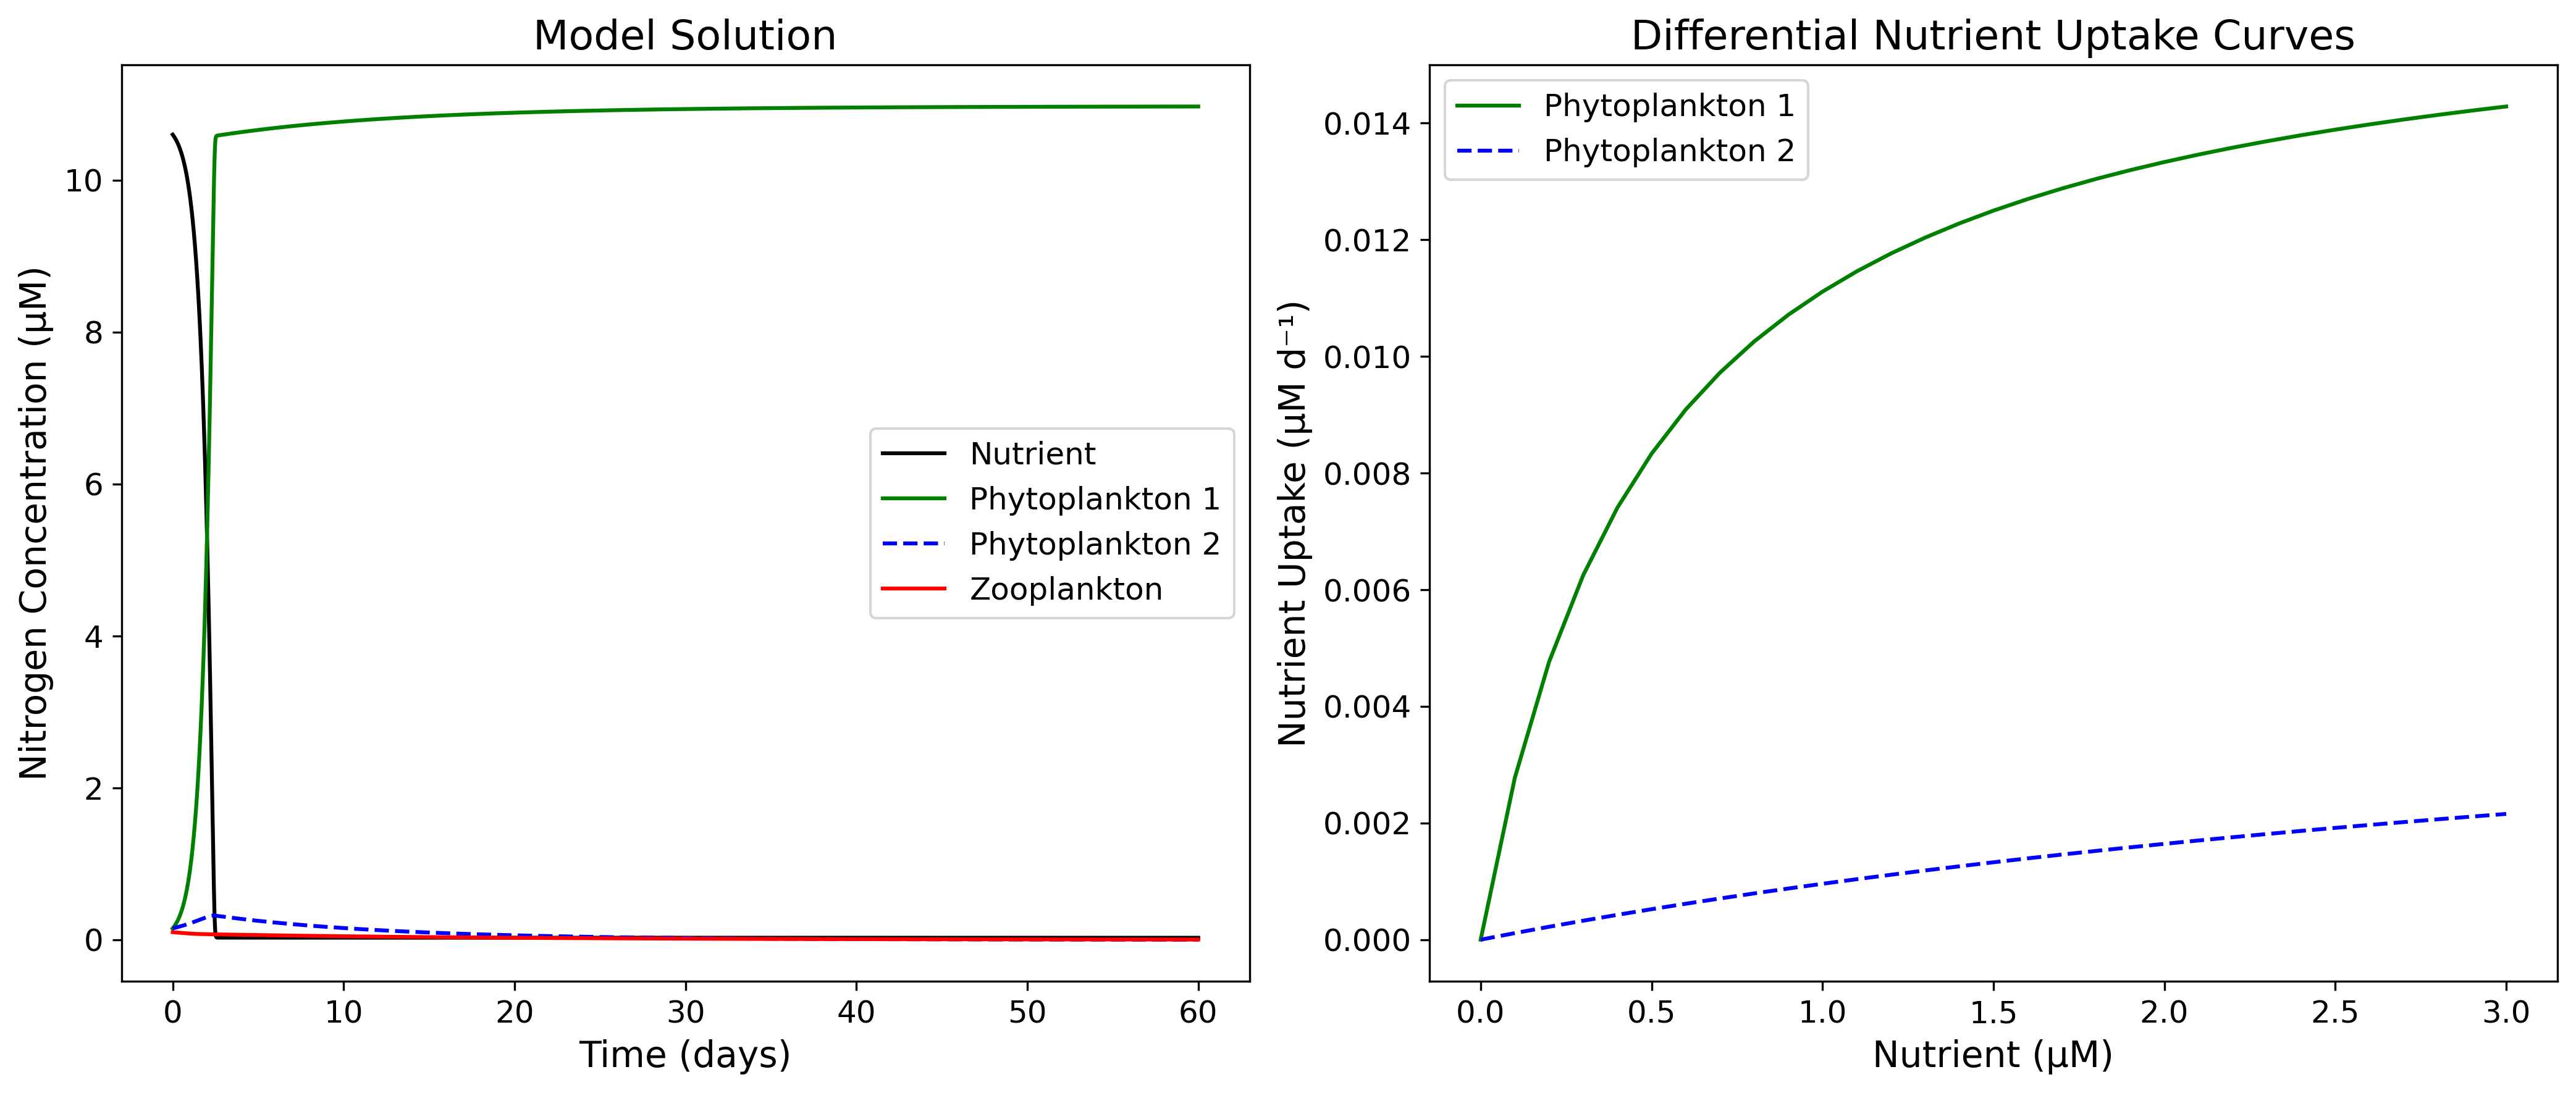

In [48]:
# copy the code in the cell below to keep this as a reference

# Assign length of run and Time Step
ndays = 60
nsteps = 120

# Set Initial conditions
N = 10.6                            # nutrient concentration
P1 = 0.15                           # phytoplankton 1
P2 = 0.15                           # phytoplankton 2
Z = 0.1                             # zooplankton

## Biological Parameter Values
# Set values of all parameters for standard run. Daily rates are reduced for small time steps
# Biological Parameter Values (Daily rates are scaled for small time steps) 
# Note, we now must define parameter for both phytoplankton groups! 1 and 2

umax1 = 2.0 / nsteps                # maximum phytoplankton growth rate
umax2 = 0.69 / nsteps               # maximum phytoplankton growth rate
mp = 0.1 / nsteps                   # phytoplankton mortlality rate
gmax1 = 0.5 / nsteps                # maximum zooplankton grazing rate
gmax2 = 2.0 / nsteps                # maximum zooplankton grazing rate
mz = 0.2 / nsteps                   # zooplankton mortlality rate
Gamma = 0.3                         # grazing efficiency
KN1 = 0.5                           # half saturation concentration for nutrient uptake
KN2 = 5                             # half saturation concentration for nutrient uptake
KZ = 0.5                            # half saturation concentration for grazing      
P0 = 1.0                            # minimum phytopankton threshold

# Mixing Parameters
# Mixing with deeper water adds nurtients and removes some organic matter   

mixingON = False                    # turn on and off using 'True' and 'False'
Mix = 0.02 / nsteps                 # mixing rate (fraction of box mixed per day) 
deepN = 10.6                        # nutrient concentration in the deep
sp = 0.6                            # fraction of dead phytoplankton POC that sinks out of surface
sz = 0.4                            # fraction of dead zooplankton and sloppy feeding POC that sinks out of surface

# Run Model

# Initialize arrays with initial conditions
Tct = np.array([0])
P1ct = np.array([P1])
P2ct = np.array([P2])
Nct = np.array([N])
Zct = np.array([Z])

ct = 0   # Initialize timing step
for i in range(ndays):
    # autum mixing, in MixingON is set to 'true'
    if mixingON and i > 120:
        Mix += 0.02 / nsteps

    # subloop to allow nstep time steps per day
    for j in range(nsteps):
        ct += 1

        # Phytoplankton growth at given N concentration
        mu1 = umax1 * (N / (KN1 + N))          # phytoplankton group 1
        mu2 = umax2 * (N / (KN2 + N))          # phytoplankton group 2

        # Zooplankton grazing rate
        graze1 = gmax1 * ((P1 - P0) / (KZ + (P1 - P0))) if P1 > P0 else 0      #  if conditional to prevent grazing if P1 is below minimum value (PO) 
        graze2 = gmax2 * ((P2 - P0) / (KZ + (P2 - P0))) if P2 > P0 else 0      #  if conditional to prevent grazing if P2 is below minimum value (PO) 

        # Compute differential equations
        delP1 = mu1 * P1 - mp * P1 - graze1 * Z                                # phytoplankton group 1
        delP2 = mu2 * P2 - mp * P2 - graze2 * Z                                # phytoplankton group 2
        delZ = Gamma * graze1 * Z + Gamma * graze2 * Z - mz * Z                # zooplankton
                      
        if mixingON:                                                            # nutrients if mixing is ON
            delN = -mu1 * P1 - mu2 * P2 + sp * mp * P1 + sp * mp * P2 + sz * mz * Z + sz * (1 - Gamma) * graze1 * Z + sz * (1 - Gamma) * graze2 * Z + Mix * (deepN - N)
        else:                                                                  # nutrients if mixing is OFF
            delN = -mu1 * P1 - mu2 * P2 + mp * P1 + mp * P2 + mz * Z + (1 - Gamma) * graze1 * Z + (1 - Gamma) * graze2 * Z

        # Update values
        P1 += delP1
        P2 += delP2
        Z += delZ
        N += delN

        # add new  variables to timeseries
        Tct = np.append(Tct, ct/nsteps)
        Nct = np.append(Nct, N)
        P1ct = np.append(P1ct, P1)
        P2ct = np.append(P2ct, P2)
        Zct = np.append(Zct, Z)



# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

# Plot concentrations over time
axs[0].plot(Tct, Nct, 'k', linewidth=1.5, label='Nutrient')
axs[0].plot(Tct, P1ct, 'g', linewidth=1.5, label='Phytoplankton 1')
axs[0].plot(Tct, P2ct, 'b--', linewidth=1.5, label='Phytoplankton 2')
axs[0].plot(Tct, Zct, 'r', linewidth=1.5, label='Zooplankton')
axs[0].legend(fontsize=12)
axs[0].set_xlabel('Time (days)', fontsize=14)
axs[0].set_ylabel('Nitrogen Concentration (µM)', fontsize=14)
axs[0].set_title('Model Solution', fontsize=16)
axs[0].tick_params(axis='both', labelsize=12)

# Plot nutrient uptake curves
nutrient = np.arange(0, 3.1, 0.1)
axs[1].plot(nutrient, (umax1 * nutrient) / (KN1 + nutrient), 'g', linewidth=1.5, label='Phytoplankton 1')
axs[1].plot(nutrient, (umax2 * nutrient) / (KN2 + nutrient), 'b--', linewidth=1.5, label='Phytoplankton 2')
axs[1].legend(fontsize=12)
axs[1].set_xlabel('Nutrient (µM)', fontsize=14)
axs[1].set_ylabel('Nutrient Uptake (µM d⁻¹)', fontsize=14)
axs[1].set_title('Differential Nutrient Uptake Curves', fontsize=16)
axs[1].tick_params(axis='both', labelsize=12)

plt.tight_layout()
#fig.savefig('Franks2sppFig1.jpg')
plt.show()

**************************
### Question 4. What values of KN, umax, and gmax did you have to use for each species to achieve coexistence? 
**************************

In [49]:
# insert working example here



### Part 6: 
In the lectures we discussed phytoplankton functional types on a very basic level. That is, we talked about:


a Diatoms need Si to make their glass shells in addition to the ‘regular’ macronutrients N and P..

 Diazotrophs like trichodesmium. They have specific enzymes which can break down dissolved gaseous N2 into a usable form of N.
fc)	Coccolithophorids like Emiliania huxleyi. They make CaCO3 shells. The process of CaCO3 precipitation impacts ocean alkalinity and pCO2.O2


Realistically, successful models need to simulate these processes and you will learn more about this later in the week. The model we have used today is extremely simple.atom?


***************************
#### Question 5. How would you take our last function and make the 2nd phytoplankton species a diatom? That is, what equations or variables or both would you need to add to make P2 behave like a diatom?

•	What key variable (i.e. tracer) is missing from the current model to accurately simulate the constraints on Diatom growth?

•	In turn, what addition variables (i.e. tracers) and/or equations would you need to add? 

•	How would parameter values (e.g. KN, umax, and gmax) compare to those of small phytoplankton? Hint: See ‘The Representation of Phytoplankton slide in the Bonus ‘Introduction to BGC Modelling Lecture’ from Week 1.

***************************

******
**Answer.**

- slower growth rate because big
- Smaller grazing because shell
-  Kn don’t know

- Eq. could put In a silica constraint
- make them sink out faster becausee big and heavy and don't get ebecause of their shells
lls.
